# Simplest use case

## Running a model from the config file

Setting up the `dolphin` ecosystem:

- Install `dolphin`, `lenstronomy`, and the required dependencies.
- Create an input/output directory for `dolphin`, we are using "../io_directory_example" in this example.
- Set up these directories inside the input/output directory. Look inside "../io_directory_example" for example. 
    - **data**: contains subdirectories for each lens system with a data and PSF files for each band.
    - **settings**: contains the 'config_{lens_name}.yaml' files for each lens system,
        - **masks**: contains the custom 'mask_{lens_name}_{band}.npy' files (optional),
    - **logs**: to write the log files from model runs,
    - **outputs**: to save the model outputs,
    - **hpc**: *optional*, contains scripts to submit batch jobs in MPI.
 

   
### Data format

The image data file needs to be in the hdf5 format with the following datasets:

- `image_data`: reduced and background subtracted image cutout centered at the lens system,
- `background_rms`: background level,
- `exposure_time`: the map of exposure times for each pixel, so that `image_data * exposure_time` is Poisson noise distributed,
- `ra_at_xy_0`: RA of the (0, 0) pixel in the `image_data` cutout,
- `dec_at_xy_0`: Dec of the (0, 0) pixel in the `image_data` cutout,
- `transform_pix2angle`: a transform matrix to map the pixel numbers (x, y) to angles (RA, Dec).

The PSF data file needs to be in the hdf5 format with the following datasets:

- `kernel_point_source`: a pixelated PSF (not required to have the same dimension of `image_data`),
- `psf_variance_map`: *optional*, uncertainty in the provided PSF, needs to have the same dimension of `kernel_point_source`. 

### Config file format

The 'config_{lens_name}.yaml' file provides you options to set up the lens model. Here is the content of the config file that is used in the example model below.

### Imports

In [34]:
from dolphin.processor import Processor
from dolphin.analysis.output import Output

import os
import multiprocessing

### create a `Processor` instance and point to the IO directory

In [35]:
processor = Processor("../io_directory_example/")

In [36]:
lens_name = "lens_system1"
model_id = "gradient_descent"  # gradient_descent example
recipe_name = "galaxy-galaxy-pso-gradient-descent"  # galaxy-galaxy galaxy-galaxy-pso-gradient-descent

### Run a model by calling the  `swim()` method

In [37]:
# processor.swim(lens_name="lens_system1", model_id="example", log=False, use_jax=True)

One can also perform the fitting sequence through JAXtronomy by setting the `use_jax` flag. For parallelization across CPU cores, an environment variable also needs to be set.

In [38]:
# Restrict JAX to one device before it is imported. Without this, JAX initializes
# every installed backend plugin, and a CUDA plugin claims memory on *every* visible
# GPU -- even when the computation runs on the CPU.
from dolphin.util import select_jax_device

# Pin the fourth A6000 (index 4 in `nvidia-smi`; index 0 is the small T400 display
# adapter). Passing the UUID rather than the index sidesteps CUDA_DEVICE_ORDER: CUDA
# enumerates fastest-first by default, so its index 4 need not be this card.
select_jax_device(device="GPU-e1043ca8-aa05-30dd-2b36-253cdc3c6e4e")

# To run on the CPU instead, parallelized across cores:
#
#     num_cores = multiprocessing.cpu_count()
#     select_jax_device("cpu", host_device_count=num_cores)
#
# `get_least_used_gpu()` picks the GPU with the most free memory automatically.

JAX restricted to: JAX_PLATFORMS=cuda,cpu, CUDA_DEVICE_ORDER=PCI_BUS_ID, CUDA_VISIBLE_DEVICES=GPU-e1043ca8-aa05-30dd-2b36-253cdc3c6e4e, XLA_PYTHON_CLIENT_PREALLOCATE=false


/tmp/ipykernel_1783696/1527672305.py:9: RuntimeWarning: JAX has already been imported, so `select_jax_device` cannot take effect. The backend and the set of visible devices are fixed when JAX is first imported, and there is no runtime override for them, unlike `enable_jax_x64`. JAX will keep using the devices it picked up, and a CUDA plugin may already have claimed memory on every visible GPU. Call `select_jax_device` before importing `jax`, `jaxtronomy` or `dolphin.util.jax_util`; in a notebook, restart the kernel and call it in the first cell.
  select_jax_device(device="GPU-e1043ca8-aa05-30dd-2b36-253cdc3c6e4e")


{'JAX_PLATFORMS': 'cuda,cpu',
 'CUDA_DEVICE_ORDER': 'PCI_BUS_ID',
 'CUDA_VISIBLE_DEVICES': 'GPU-e1043ca8-aa05-30dd-2b36-253cdc3c6e4e',
 'XLA_PYTHON_CLIENT_PREALLOCATE': 'false'}

In [39]:
processor.swim(
    lens_name=lens_name,
    model_id=model_id,
    log=False,
    use_jax=True,
    recipe_name=recipe_name,
)

Optimizing model for lens_system1 with recipe: galaxy-galaxy-pso-gradient-descent.
starting PSO optimization
iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19
iteration 20
iteration 21
iteration 22
iteration 23
iteration 24
-0.6094394921567242 reduced X^2 of best position
-127.37285386075537 log likelihood
418 effective number of data points
[{'theta_E': 1.2, 'gamma': 2.0, 'e1': 0.05, 'e2': -0.05, 'center_x': np.float64(-0.012547524444344246), 'center_y': np.float64(-0.04137115492759486)}, {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'R_sersic': 0.2, 'n_sersic': 1.0, 'e1': 0.0, 'e2': 0.0, 'center_x': 0.0, 'center_y': 0.0}, {'amp': 1, 'n_max': 10, 'beta': 0.1, 'center_x': 0.0, 'center_y': 0.0}] source result
[{'amp': 1, 'R_sersic': np.float64(4.1143258

## Let's check the output

In [40]:
output = Output("../io_directory_example/")

Loaded output for lens_system1 with model ID gradient_descent.
dolphin version used: 1.4.0
lenstronomy version used: 1.14.1
jaxtronomy version used: 0.1.4
-1.003363905692409 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.003363905692412


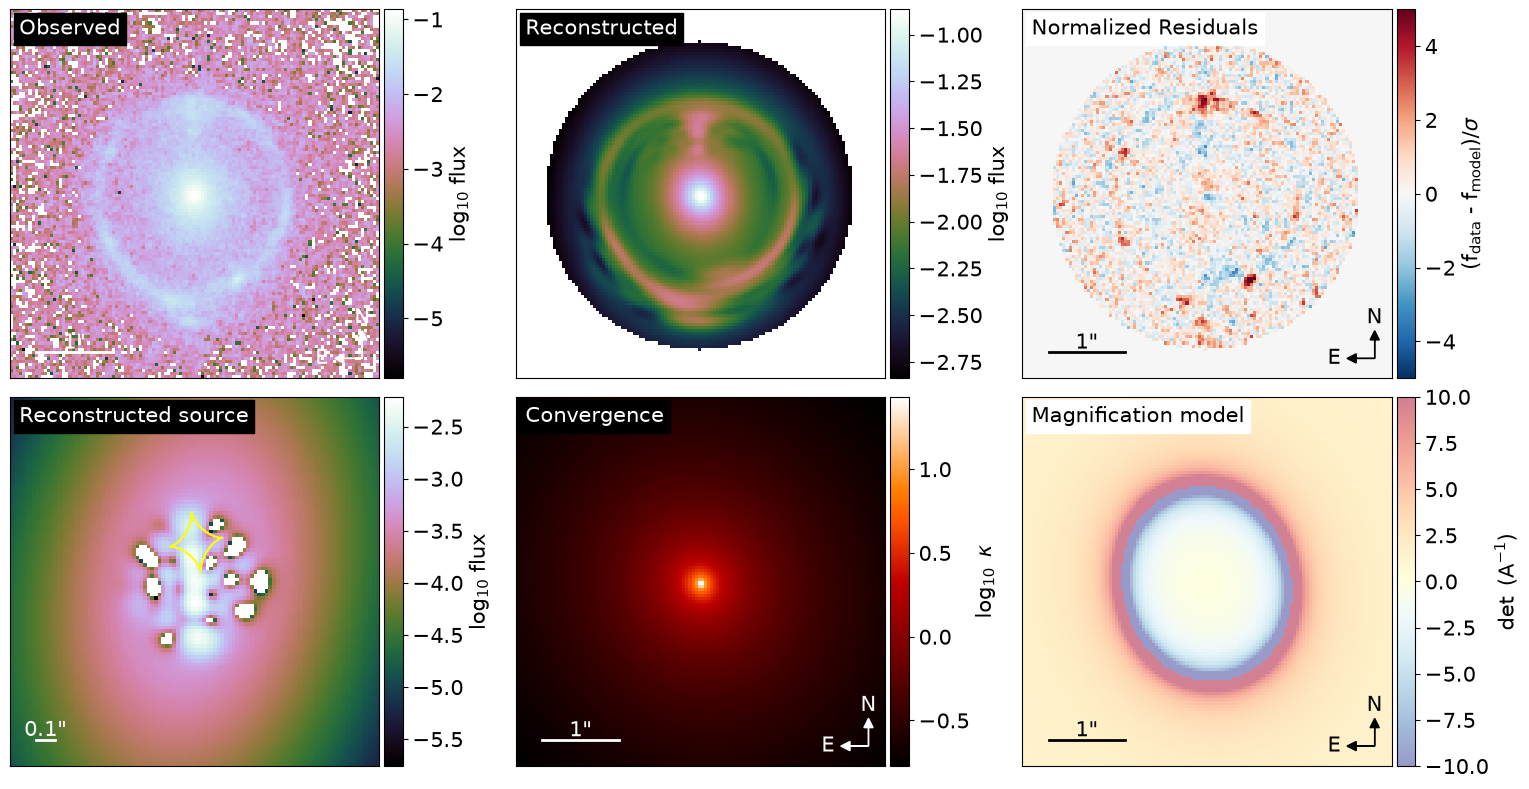

In [41]:
fig = output.plot_model_overview(lens_name=lens_name, model_id=model_id)

We only ran a pre-sampling optimization here and did not perform a MCMC sampling. So, the above model is the optimized model that the MCMC sample can initiate from. The `kwargs_result` dictionary of the pre-sampling optimization step can be accessed through `Output.kwargs_result` after loading an output using the `Output.load_output()` method.

In [42]:
output.load_output(lens_name=lens_name, model_id=model_id)

output.kwargs_result

Loaded output for lens_system1 with model ID gradient_descent.
dolphin version used: 1.4.0
lenstronomy version used: 1.14.1
jaxtronomy version used: 0.1.4


{'kwargs_lens': [{'theta_E': array(1.1816983),
   'gamma': 2.0,
   'e1': array(-0.01647194),
   'e2': array(0.03145883),
   'center_x': array(0.02049685),
   'center_y': array(-0.05067194)},
  {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}],
 'kwargs_source': [{'amp': 1,
   'R_sersic': array(0.49999714),
   'n_sersic': array(0.80387968),
   'e1': array(-0.21400841),
   'e2': array(-0.08201056),
   'center_x': array(0.028291),
   'center_y': array(-0.26554953)},
  {'amp': 1,
   'n_max': 10,
   'beta': array(0.08751123),
   'center_x': array(0.028291),
   'center_y': array(-0.26554953)}],
 'kwargs_lens_light': [{'amp': 1,
   'R_sersic': array(1.65393805),
   'n_sersic': 4.0,
   'e1': array(-0.05948582),
   'e2': array(0.03769401),
   'center_x': array(0.02049685),
   'center_y': array(-0.05067194)}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

When necessary, the settings of the model run---that was read out of the 'config_{lens_name}.yaml' file---can be accessed through the `output.model_settings` variable.

In [43]:
output.model_settings

{'lens_name': 'lens_system1',
 'band': ['F390W'],
 'model': {'lens': ['EPL', 'SHEAR_GAMMA_PSI'],
  'lens_light': ['SERSIC_ELLIPSE'],
  'source_light': ['SERSIC_ELLIPSE', 'SHAPELETS'],
  'point_source': []},
 'lens_options': {'centroid_init': [0.04, -0.04],
  'centroid_bound': 0.2,
  'limit_mass_pa_from_light': 15,
  'limit_mass_q_from_light': 0,
  'initial_guesses': {'0': {'theta_E': 1.2, 'e1': 0.05, 'e2': -0.05}}},
 'lens_light_options': {'fix': {'0': {'n_sersic': 4.0}}},
 'source_light_options': {'n_max': [10]},
 'point_source_options': {'ra_init': [], 'dec_init': [], 'bound': 0.0},
 'kwargs_constraints': {'joint_lens_with_light': [[0,
    0,
    ['center_x', 'center_y']]]},
 'fitting': {'psf_iteration': False,
  'psf_iteration_settings': None,
  'pso': True,
  'pso_settings': {'num_particle': 100, 'num_iteration': 100},
  'sampling': False,
  'sampler': 'emcee',
  'sampler_settings': {'n_burn': 2000, 'n_run': 3000, 'walkerRatio': 6}},
 'kwargs_model': None,
 'numeric_options': {'sup

### Checking the particle swarm optimization

The chain of any particle swarm step in the fitting sequence can be plotted with the `Output.plot_pso_chain()` method. The `index` keyword picks the step among the PSO steps of the recipe only, so the default `index=-1` shows the last swarm, and `index=0` the first one. The panels show the likelihood, the position, and the velocity of the best particle at each iteration.

Note that the PSO in JAXtronomy does not store the chain, so this needs an output from a run with `use_jax=False`. Outputs from runs with `use_jax=True` have empty PSO chains, and `plot_pso_chain()` raises a `ValueError` for them.

In [44]:
# fig = output.plot_pso_chain(lens_name=lens_name, model_id=model_id)